In [1]:
# Mount Google Drive to access dataset and save results
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Copy dataset from Google Drive to Colab local environment (faster I/O)
!cp -r "/content/drive/dataset-images" /content/ # Relative Path

In [ ]:
# ================================
# Import Libraries
# ================================
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import AveragePooling2D, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import matplotlib.image as mping
import numpy as np
import argparse
import cv2
import os
import sys
import tensorflow as tf
import h5py
import numpy as np
import sys

In [ ]:
# ================================
# Data Augmentation Note
# ================================
# NOTE:
# Data augmentation is applied to both training and validation datasets.
# As a result, the validation accuracy may be slightly biased and not perfectly reflect real-world performance.
# In a production or more rigorous setting, it is recommended to separate train and validation directories
# and apply augmentation only to the training data.

# ================================
# Hyperparameters
# ================================
IMAGE_DIRECTORY = '/content/dataset-images' # Relative Path
IMAGE_SIZE = 128
BS = 64
EPOCHS = 100

# ================================
# Data Generator (with Augmentation)
# ================================
datagen  = ImageDataGenerator(preprocessing_function = preprocess_input,
                                    rotation_range = 30,
                                    zoom_range = 0.3,
                                    horizontal_flip = True,
                                    width_shift_range = 0.1,
                                    height_shift_range = 0.1,
                                    validation_split=0.2)

# Training data generator
train_generator = datagen.flow_from_directory(IMAGE_DIRECTORY,
                                              target_size = (IMAGE_SIZE,IMAGE_SIZE),
                                              batch_size = 32,
                                              color_mode = 'rgb',
                                              class_mode = 'categorical',
                                              subset = 'training')

# Validation data generator
validation_generator = datagen.flow_from_directory(IMAGE_DIRECTORY,
                                                   target_size = (IMAGE_SIZE,IMAGE_SIZE),
                                                   batch_size = 32,
                                                   color_mode = 'rgb',
                                                   class_mode = 'categorical',
                                                   subset = 'validation',
                                                   shuffle=False)


# ================================
# Class Information
# ================================
num_classes = train_generator.num_classes
print("Number of classes:", num_classes)
print(train_generator.class_indices)

Found 271 images belonging to 7 classes.
Found 67 images belonging to 7 classes.
Number of classes: 7
{'car-bus': 0, 'car-sedan': 1, 'car-suv': 2, 'motocycle-bicycle-kids': 3, 'motocycle-bicycle-racing': 4, 'motocycle-motorbike-chopper': 5, 'motocycle-motorbike-sport': 6}


In [ ]:
# ================================
# Load Pretrained Model (MobileNetV2)
# ================================
baseModel = MobileNetV2(weights = 'imagenet', include_top = False, input_shape = (IMAGE_SIZE,IMAGE_SIZE,3))

# Freeze all layers (transfer learning)
for layer in baseModel.layers:
    layer.trainable = False

# Unfreeze top layers for fine-tuning
for layer in baseModel.layers[-20:]:
    layer.trainable = True

In [ ]:
# ================================
# Custom Classification Head
# ================================
headModel = baseModel.output
headModel = GlobalAveragePooling2D()(headModel)
headModel = Dense(128, activation = 'relu')(headModel)
headModel = BatchNormalization()(headModel)
headModel = Dense(64, activation = 'relu')(headModel)
headModel = Dropout(0.5)(headModel)
headModel = BatchNormalization()(headModel)

# Output layer (number of classes)
headModel = Dense(num_classes,activation = 'softmax')(headModel)

# Combine base model and head model
model = Model(inputs = baseModel.input, outputs = headModel)

# ================================
# Compile Model
# ================================
model.compile(loss = 'categorical_crossentropy', optimizer = Adam(learning_rate = 1e-4), metrics = ['accuracy'])

In [ ]:
# ================================
# Callbacks (Training Control)
# ================================
checkpoint_path = '/content/drive/checkpoint.keras' # Relative Path
cp1 = ModelCheckpoint(filepath = checkpoint_path, monitor = 'val_accuracy', save_best_only = True, verbose = 1, mode = 'auto')

# Save training logs
logger_path = '/content/drive/logger.csv' # Relative Path
csv_logger = CSVLogger(logger_path, append = True)

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor = 'val_loss',patience = 10,restore_best_weights = True)

callback_list = [cp1, csv_logger, early_stop]

In [ ]:
# ================================
# Model Training
# ================================
history = model.fit(train_generator,
                    batch_size = BS,
                    epochs = EPOCHS,
                    verbose = 1,
                    validation_data = validation_generator,
                    callbacks = callback_list)

# ================================
# Save Final Model
# ================================
model.save('/content/drive/car-classification-model.keras') # Relative Path

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1282 - loss: 2.6751   
Epoch 1: val_accuracy improved from None to 0.20896, saving model to /content/drive/MyDrive/Colab Notebooks/transferlearning/car-classification/checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/transferlearning/car-classification/checkpoint.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.1587 - loss: 2.5223 - val_accuracy: 0.2090 - val_loss: 1.8518
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.2401 - loss: 2.0056
Epoch 2: val_accuracy improved from 0.20896 to 0.43284, saving model to /content/drive/MyDrive/Colab Notebooks/transferlearning/car-classification/checkpoint.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/transferlearning/car-classification/checkpoint.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 663ms/step - accuracy: 0.3026 - loss: 1.9434 - val_accuracy: 0.4328 - val_loss: 1.5224
Epoch 3/100
9/9 ━━━━━━━

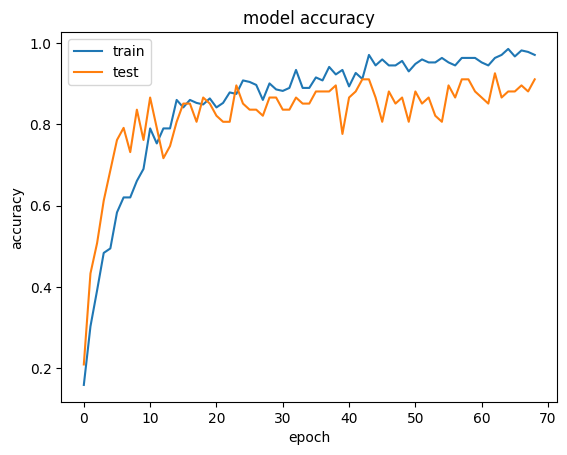

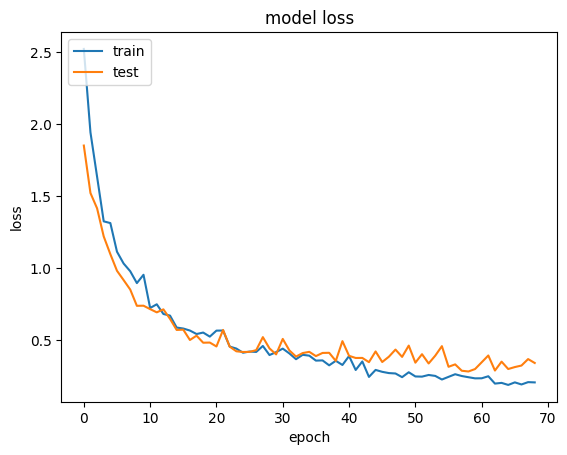

<Figure size 640x480 with 0 Axes>

In [ ]:
# ================================
# Training History Visualization
# ================================
def plot_history(history):

  # summarize history for accuracy
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title('model accuracy')
  plt.ylabel('accuracy')
  plt.xlabel('epoch')
  plt.legend(['train', 'test'], loc='upper left')
  plt.show()

  # summarize history for loss
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('model loss')
  plt.ylabel('loss')
  plt.xlabel('epoch')
  plt.legend(['train', 'test'], loc='upper left')
  plt.show()

# Plot training results
plot_history(history)